In [ ]:
# !pip3 install pandas numpy matplotlib scipy

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)

## Configuration

In [13]:
NAME     = "a_5_0"   # scheme name — matches the filenames
NODE_IDS = [0, 1, 2, 3, 4] # node IDs present in the experiment
DATA_DIR = "./data"

## Load node logs

In [14]:
traces = {}
for nid in NODE_IDS:
    path = f"{DATA_DIR}/node_{nid}_{NAME}.csv"
    df = pd.read_csv(path)
    df = df.sort_values("timestamp_usec").reset_index(drop=True)
    df["timestamp_sec"] = df["timestamp_usec"] / 1e6
    traces[nid] = df
    print(f"Node {nid}: {len(df)} events")

# Combine into one dataframe for cross-node queries
all_events = pd.concat(traces.values(), ignore_index=True).sort_values("timestamp_usec").reset_index(drop=True)
all_events.head(10)

Node 0: 4749 events
Node 1: 241 events
Node 2: 4749 events
Node 3: 4753 events
Node 4: 4685 events


,node_id,timestamp_usec,event,term,leader_id,value,timestamp_sec
0,4,24281385840,starting,-1,-1,-1,24281.385840
1,4,24281388143,timeout,0,-1,0,24281.388143
2,4,24282258478,became_candidate,1,-1,0,24282.258478
3,4,24282263767,became_follower,2,0,0,24282.263767
4,4,24283266343,became_follower,3,1,1,24283.266343
5,4,24283985054,heartbeat,3,1,500744,24283.985054
6,4,24284485521,heartbeat,3,1,500463,24284.485521
7,4,24284986395,heartbeat,3,1,500877,24284.986395
8,4,24285486973,heartbeat,3,1,500579,24285.486973
9,4,24285987498,heartbeat,3,1,500525,24285.987498


## Identify crash terms

An `intentional_crash` event in term **T** means we should look for the next leader election in term **T+1**.
Detection time = `became_leader (T+1)` − `last heartbeat before timeout in term T` on the node that detected the crash.

In [15]:
crash_events = all_events[all_events["event"] == "intentional_crash"].copy()
print(f"Found {len(crash_events)} intentional crashes")
crash_events[["node_id", "timestamp_sec", "term", "leader_id"]]

Found 47 intentional crashes


,node_id,timestamp_sec,term,leader_id
819,1,24436.514531,3,-1
1211,1,24495.629759,4,-1
1623,1,24558.073659,5,-1
2029,1,24618.694713,6,-1
2434,1,24680.112127,7,-1
2854,1,24742.691068,8,-1
3264,1,24802.974719,9,-1
3678,1,24862.348377,10,-1
4075,1,24919.611303,11,-1
4464,1,24979.659432,12,-1


In [16]:
MAX_TERM_SEARCH = 10

records = []

for _, crash in crash_events.iterrows():
    crash_term = int(crash["term"])

    # --- Find became_leader in T+1, T+2, ... up to MAX_TERM_SEARCH ---
    leader_row    = None
    election_term = None
    for offset in range(1, MAX_TERM_SEARCH + 1):
        candidate_term = crash_term + offset
        leader_rows = all_events[
            (all_events["event"] == "became_leader") &
            (all_events["term"]  == candidate_term)
        ]
        if not leader_rows.empty:
            election_term = candidate_term
            leader_row = leader_rows.sort_values("timestamp_usec").iloc[0]
            if offset > 1:
                print(f"  [INFO] Crash term {crash_term}: leader found at term {election_term} "
                      f"(after {offset - 1} failed election(s))")
            break

    if leader_row is None:
        print(f"  [SKIP] Crash term {crash_term}: no became_leader within {MAX_TERM_SEARCH} terms — skipping")
        continue

    new_leader_id = int(leader_row["node_id"])
    t_leader      = leader_row["timestamp_sec"]

    # --- Find the last heartbeat before the timeout on the new leader's node ---
    # Accept timeouts in any term between crash_term and election_term (inclusive)
    node_trace = traces[new_leader_id]

    timeout_rows = node_trace[
        (node_trace["event"] == "timeout") &
        (node_trace["term"].between(crash_term, election_term))
    ]

    if timeout_rows.empty:
        print(f"  [WARN] No timeout found on node {new_leader_id} for terms {crash_term}->{election_term}")
        continue

    # Use the first timeout that precedes became_leader
    timeout_row = timeout_rows[
        timeout_rows["timestamp_usec"] < leader_row["timestamp_usec"]
    ].sort_values("timestamp_usec").iloc[0]

    t_timeout = timeout_row["timestamp_sec"]

    # Last heartbeat strictly before that first timeout
    hb_before = node_trace[
        (node_trace["event"]         == "heartbeat") &
        (node_trace["timestamp_usec"] < timeout_row["timestamp_usec"])
    ]

    if hb_before.empty:
        # The crashed leader was re-elected — no prior heartbeat on this node.
        # Fall back to the actual crash timestamp.
        crash_row = all_events[
            (all_events["event"] == "intentional_crash") &
            (all_events["term"]  == crash_term)
        ]
        if crash_row.empty:
            print(f"  [WARN] No heartbeat or crash event found for crash term {crash_term} — skipping")
            continue
        t_last_hb = crash_row.sort_values("timestamp_usec").iloc[-1]["timestamp_sec"]
        print(f"  [INFO] Crash term {crash_term}: no prior heartbeat on node {new_leader_id} — using crash time as anchor")
        anchor = "crash_time"
    else:
        last_hb   = hb_before.sort_values("timestamp_usec").iloc[-1]
        t_last_hb = last_hb["timestamp_sec"]
        anchor = "last_heartbeat"

    detection_time_sec = t_leader - t_last_hb

    records.append({
        "crash_term":       crash_term,
        "election_term":    election_term,
        "failed_elections": election_term - crash_term - 1,
        "new_leader":       new_leader_id,
        "t_last_heartbeat": t_last_hb,
        "t_timeout":        t_timeout,
        "t_became_leader":  t_leader,
        "detection_sec":    detection_time_sec,
        "detection_ms":     detection_time_sec * 1000,
        "anchor":           anchor,
    })

results = pd.DataFrame(records)
print(f"\nSuccessfully measured {len(results)} crash-detection events")
results


  [INFO] Crash term 3: no prior heartbeat on node 1 — using crash time as anchor
  [INFO] Crash term 4: no prior heartbeat on node 1 — using crash time as anchor
  [INFO] Crash term 5: no prior heartbeat on node 1 — using crash time as anchor
  [INFO] Crash term 6: no prior heartbeat on node 1 — using crash time as anchor
  [INFO] Crash term 7: no prior heartbeat on node 1 — using crash time as anchor
  [INFO] Crash term 8: no prior heartbeat on node 1 — using crash time as anchor
  [INFO] Crash term 9: no prior heartbeat on node 1 — using crash time as anchor
  [INFO] Crash term 10: no prior heartbeat on node 1 — using crash time as anchor
  [INFO] Crash term 11: no prior heartbeat on node 1 — using crash time as anchor
  [INFO] Crash term 12: no prior heartbeat on node 1 — using crash time as anchor
  [INFO] Crash term 13: no prior heartbeat on node 1 — using crash time as anchor
  [INFO] Crash term 14: no prior heartbeat on node 1 — using crash time as anchor
  [INFO] Crash term 15:

,crash_term,election_term,failed_elections,new_leader,t_last_heartbeat,t_timeout,t_became_leader,detection_sec,detection_ms,anchor
0,3,4,0,1,24436.514531,24441.525129,24442.205909,5.691378,5691.378,crash_time
1,4,5,0,1,24495.629759,24500.640418,24501.311312,5.681553,5681.553,crash_time
2,5,6,0,1,24558.073659,24563.084739,24563.786405,5.712746,5712.746,crash_time
3,6,7,0,1,24618.694713,24623.705332,24624.387003,5.692290,5692.290,crash_time
4,7,8,0,1,24680.112127,24685.123205,24685.835964,5.723837,5723.837,crash_time
5,8,9,0,1,24742.691068,24747.702007,24748.382050,5.690982,5690.982,crash_time
6,9,10,0,1,24802.974719,24807.985413,24808.635016,5.660297,5660.297,crash_time
7,10,11,0,1,24862.348377,24867.359377,24868.014488,5.666111,5666.111,crash_time
8,11,12,0,1,24919.611303,24924.622315,24925.300646,5.689343,5689.343,crash_time
9,12,13,0,1,24979.659432,24984.669728,24985.313692,5.654260,5654.260,crash_time


## Summary statistics

In [17]:
desc = results["detection_ms"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])
print(f"Scheme: {NAME}")
print("\n--- Detection + replacement time (ms) ---")
print(desc.to_string())
print(f"\nMean:   {results['detection_ms'].mean():.1f} ms")
print(f"Median: {results['detection_ms'].median():.1f} ms")
print(f"p95:    {results['detection_ms'].quantile(0.95):.1f} ms")

print("\n--- Election cycles to successful leader (failed_elections = rounds before success) ---")
print(results["failed_elections"].value_counts().sort_index().rename("count").to_string())
print(f"\nMean failed elections per crash: {results['failed_elections'].mean():.2f}")
print(f"Max failed elections in one crash: {results['failed_elections'].max()}")


Scheme: a_5_0

--- Detection + replacement time (ms) ---
count      47.000000
mean     5697.216447
std        21.960948
min      5654.260000
25%      5682.256000
50%      5692.676000
75%      5714.958500
95%      5733.697500
max      5735.421000

Mean:   5697.2 ms
Median: 5692.7 ms
p95:    5733.7 ms

--- Election cycles to successful leader (failed_elections = rounds before success) ---
failed_elections
0    47

Mean failed elections per crash: 0.00
Max failed elections in one crash: 0


## Plots

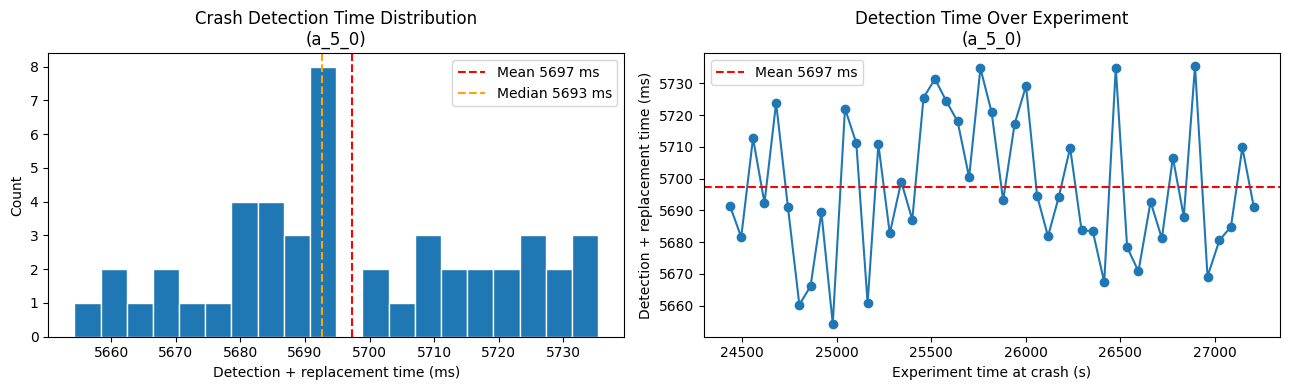

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Histogram ---
ax = axes[0]
ax.hist(results["detection_ms"], bins=20, edgecolor="white")
ax.axvline(results["detection_ms"].mean(),   color="red",    linestyle="--", label=f"Mean {results['detection_ms'].mean():.0f} ms")
ax.axvline(results["detection_ms"].median(), color="orange", linestyle="--", label=f"Median {results['detection_ms'].median():.0f} ms")
ax.set_xlabel("Detection + replacement time (ms)")
ax.set_ylabel("Count")
ax.set_title(f"Crash Detection Time Distribution\n({NAME})")
ax.legend()

# --- Over time (per crash) ---
ax = axes[1]
ax.plot(results["t_last_heartbeat"], results["detection_ms"], marker="o")
ax.axhline(results["detection_ms"].mean(), color="red", linestyle="--", label=f"Mean {results['detection_ms'].mean():.0f} ms")
ax.set_xlabel("Experiment time at crash (s)")
ax.set_ylabel("Detection + replacement time (ms)")
ax.set_title(f"Detection Time Over Experiment\n({NAME})")
ax.legend()

plt.tight_layout()
plt.show()

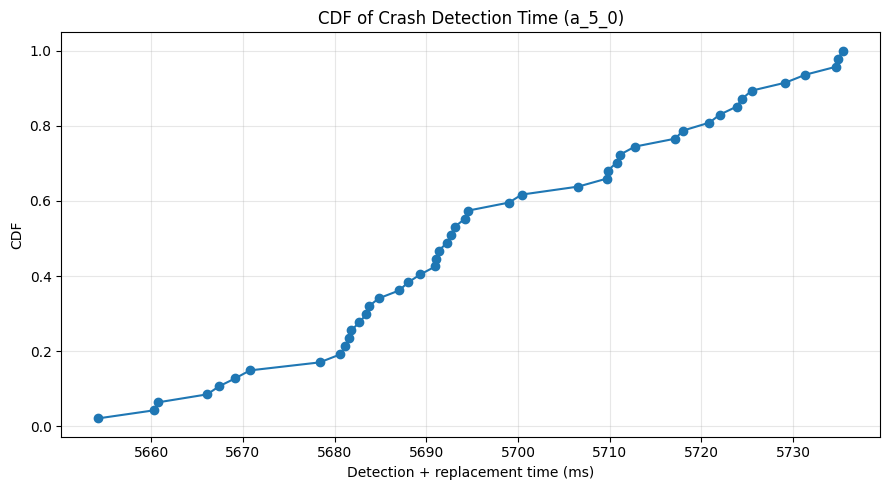

In [19]:
sorted_ms = np.sort(results["detection_ms"])
cdf = np.arange(1, len(sorted_ms) + 1) / len(sorted_ms)

plt.plot(sorted_ms, cdf, marker="o")
plt.xlabel("Detection + replacement time (ms)")
plt.ylabel("CDF")
plt.title(f"CDF of Crash Detection Time ({NAME})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Multi-scheme comparison

Configure the two sweeps below, then run the cells to compare Timeout vs Accrual schemes.

In [57]:
# Timeout schemes: parameter is the base timeout T (ms)
# Files are expected at data/node_{n}_t_{T}_{2T}.csv
TIMEOUT_PARAMS = [
    (750,  1500),
    (1000, 2000),
    (1500, 3000),
    (2000, 4000),
]  # (T_ms, 2T_ms)

# Accrual schemes: parameter is the phi threshold
# Files are expected at data/node_{n}_a_{phi}.csv
ACCRUAL_PARAMS = [
    # 4.0,
    5.0,
    6.0,
    8.0,
]  # phi threshold values

def timeout_name(t, two_t):
    return f"t_{t}_{two_t}"

def accrual_name(phi):
    return f"a_{str(phi).replace('.', '_')}"


## Core analysis function

In [58]:
def load_traces(name, node_ids, data_dir):
    traces = {}
    for nid in node_ids:
        path = f"{data_dir}/node_{nid}_{name}.csv"
        df = pd.read_csv(path)
        df = df.sort_values("timestamp_usec").reset_index(drop=True)
        df["timestamp_sec"] = df["timestamp_usec"] / 1e6
        traces[nid] = df
    return traces


def analyze_scheme(name, node_ids, data_dir, max_term_search=10):
    """Load traces for `name` and return a DataFrame of per-crash measurements."""
    try:
        traces = load_traces(name, node_ids, data_dir)
    except FileNotFoundError as e:
        print(f"  [SKIP] {name}: {e}")
        return pd.DataFrame()

    all_events = pd.concat(traces.values(), ignore_index=True).sort_values("timestamp_usec").reset_index(drop=True)
    crash_events = all_events[all_events["event"] == "intentional_crash"].copy()

    records = []
    for _, crash in crash_events.iterrows():
        crash_term = int(crash["term"])

        leader_row    = None
        election_term = None
        for offset in range(1, max_term_search + 1):
            candidate_term = crash_term + offset
            leader_rows = all_events[
                (all_events["event"] == "became_leader") &
                (all_events["term"]  == candidate_term)
            ]
            if not leader_rows.empty:
                election_term = candidate_term
                leader_row = leader_rows.sort_values("timestamp_usec").iloc[0]
                break

        if leader_row is None:
            continue

        new_leader_id = int(leader_row["node_id"])
        t_leader      = leader_row["timestamp_sec"]
        node_trace    = traces[new_leader_id]

        timeout_rows = node_trace[
            (node_trace["event"] == "timeout") &
            (node_trace["term"].between(crash_term, election_term))
        ]
        if timeout_rows.empty:
            continue

        timeout_row = timeout_rows[
            timeout_rows["timestamp_usec"] < leader_row["timestamp_usec"]
        ].sort_values("timestamp_usec").iloc[0]

        hb_before = node_trace[
            (node_trace["event"]         == "heartbeat") &
            (node_trace["timestamp_usec"] < timeout_row["timestamp_usec"])
        ]
        if hb_before.empty:
            # The crashed leader was re-elected — no heartbeat to anchor on.
            # Fall back to the actual crash timestamp.
            crash_row = all_events[
                (all_events["event"] == "intentional_crash") &
                (all_events["term"]  == crash_term)
            ]
            if crash_row.empty:
                continue
            t_last_hb = crash_row.sort_values("timestamp_usec").iloc[-1]["timestamp_sec"]
            anchor = "crash_time"
        else:
            last_hb   = hb_before.sort_values("timestamp_usec").iloc[-1]
            t_last_hb = last_hb["timestamp_sec"]
            anchor = "last_heartbeat"

        detection_ms = (t_leader - t_last_hb) * 1000
        records.append({
            "crash_term":       crash_term,
            "election_term":    election_term,
            "failed_elections": election_term - crash_term - 1,
            "new_leader":       new_leader_id,
            "t_last_heartbeat": t_last_hb,
            "t_became_leader":  t_leader,
            "detection_ms":     detection_ms,
            "anchor":           anchor,
        })

    return pd.DataFrame(records)


def scheme_summary(df):
    """Return a dict of summary statistics for a scheme's result DataFrame."""
    if df.empty:
        return None
    ms = df["detection_ms"]
    n  = len(ms)
    mean = ms.mean()
    std  = ms.std()
    sem  = std / np.sqrt(n)          # standard error of the mean
    ci95 = 1.96 * sem                # 95% CI half-width
    return {
        "n":               n,
        "mean_ms":         mean,
        "std_ms":          std,
        "sem_ms":          sem,
        "ci95_ms":         ci95,
        "median_ms":       ms.median(),
        "p25_ms":          ms.quantile(0.25),
        "p75_ms":          ms.quantile(0.75),
        "p95_ms":          ms.quantile(0.95),
        "mean_failed_elections": df["failed_elections"].mean(),
        "pct_failed_elections":  (df["failed_elections"] > 0).mean() * 100,
    }


## Run sweep

In [59]:
all_results   = {}   # name -> raw DataFrame
all_summaries = {}   # name -> summary dict

print("=== Timeout schemes ===")
for (t, two_t) in TIMEOUT_PARAMS:
    name = timeout_name(t, two_t)
    df   = analyze_scheme(name, NODE_IDS, DATA_DIR)
    all_results[name]   = df
    all_summaries[name] = scheme_summary(df)
    if all_summaries[name]:
        s = all_summaries[name]
        print(f"  {name:20s}  n={s['n']:3d}  mean={s['mean_ms']:7.1f} ms  ±{s['ci95_ms']:.1f} (95% CI)  "
              f"median={s['median_ms']:.1f}  failed_elections={s['mean_failed_elections']:.2f}")

print("\n=== Accrual schemes ===")
for phi in ACCRUAL_PARAMS:
    name = accrual_name(phi)
    df   = analyze_scheme(name, NODE_IDS, DATA_DIR)
    all_results[name]   = df
    all_summaries[name] = scheme_summary(df)
    if all_summaries[name]:
        s = all_summaries[name]
        print(f"  {name:20s}  n={s['n']:3d}  mean={s['mean_ms']:7.1f} ms  ±{s['ci95_ms']:.1f} (95% CI)  "
              f"median={s['median_ms']:.1f}  failed_elections={s['mean_failed_elections']:.2f}")


=== Timeout schemes ===
  t_750_1500            n= 97  mean= 2162.9 ms  ±320.3 (95% CI)  median=1268.9  failed_elections=0.54
  t_1000_2000           n=134  mean= 1962.1 ms  ±185.7 (95% CI)  median=1528.2  failed_elections=0.25
  t_1500_3000           n=106  mean= 2389.9 ms  ±162.4 (95% CI)  median=2169.1  failed_elections=0.13
  t_2000_4000           n=141  mean= 3050.9 ms  ±156.3 (95% CI)  median=2746.8  failed_elections=0.14

=== Accrual schemes ===
  a_5_0                 n= 47  mean= 5697.2 ms  ±6.3 (95% CI)  median=5692.7  failed_elections=0.00
  a_6_0                 n= 35  mean= 5695.8 ms  ±3.9 (95% CI)  median=5695.9  failed_elections=0.00
  a_8_0                 n= 36  mean= 5700.4 ms  ±3.9 (95% CI)  median=5698.4  failed_elections=0.00


## Comparison plots

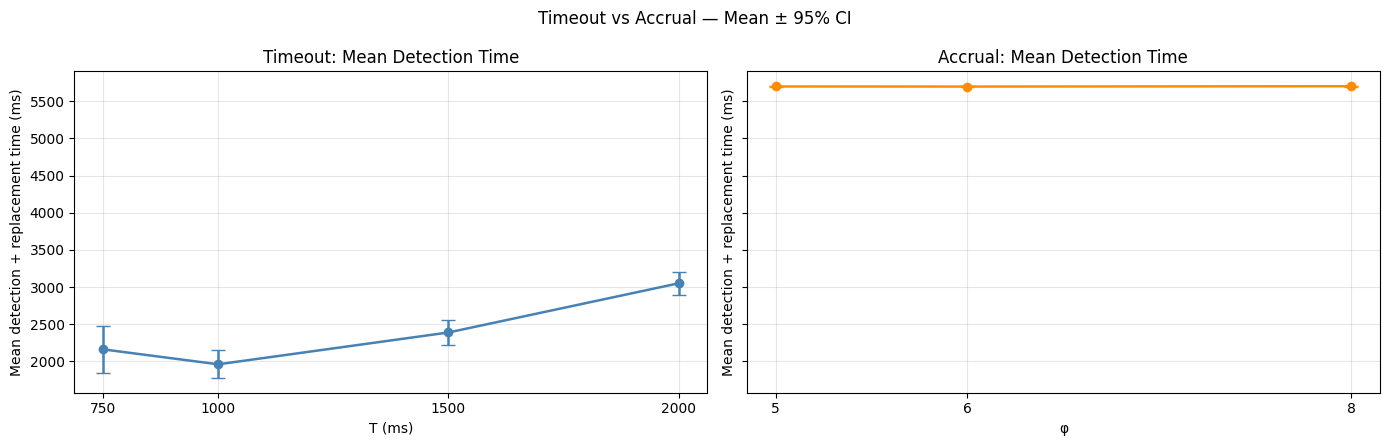

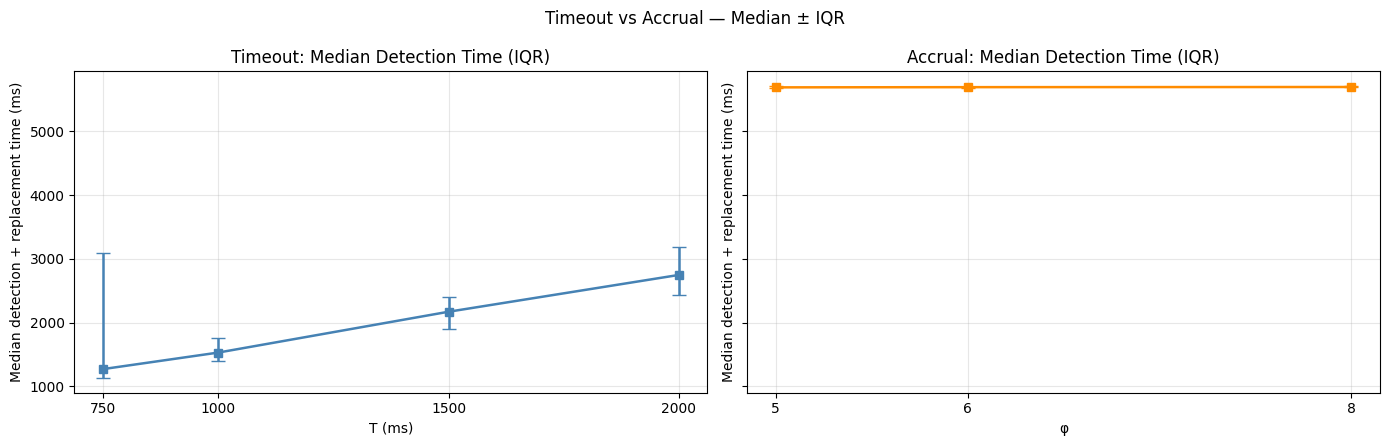

In [60]:
def prep_series(params, name_fn, label_fn):
    """Extract ordered (x_value, summary) pairs for a parameter sweep."""
    out = []
    for p in params:
        name = name_fn(*p) if isinstance(p, tuple) else name_fn(p)
        s = all_summaries.get(name)
        if s:
            x = label_fn(*p) if isinstance(p, tuple) else label_fn(p)
            out.append((x, s))
    return out

# Keep these names; later cells already use them.
t_series = prep_series(TIMEOUT_PARAMS, timeout_name, lambda t, two_t: t)
a_series = prep_series(ACCRUAL_PARAMS, accrual_name, lambda phi: phi)

# ── Plot 1: Mean + 95% CI (two axes: Timeout, Accrual) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

for ax, series, color, title, xlabel in [
    (axes[0], t_series, "steelblue", "Timeout: Mean Detection Time", "T (ms)"),
    (axes[1], a_series, "darkorange", "Accrual: Mean Detection Time", "φ"),
]:
    if series:
        xs    = [x for x, _ in series]
        means = [s["mean_ms"] for _, s in series]
        ci95  = [s["ci95_ms"] for _, s in series]
        ax.errorbar(xs, means, yerr=ci95, marker="o", color=color, capsize=5, linewidth=1.8)
        ax.set_xticks(xs)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Mean detection + replacement time (ms)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.suptitle("Timeout vs Accrual — Mean ± 95% CI")
plt.tight_layout()
plt.show()

# ── Plot 2: Median + IQR (two axes: Timeout, Accrual) ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

for ax, series, color, title, xlabel in [
    (axes[0], t_series, "steelblue", "Timeout: Median Detection Time (IQR)", "T (ms)"),
    (axes[1], a_series, "darkorange", "Accrual: Median Detection Time (IQR)", "φ"),
]:
    if series:
        xs      = [x for x, _ in series]
        medians = [s["median_ms"] for _, s in series]
        p25     = [s["p25_ms"] for _, s in series]
        p75     = [s["p75_ms"] for _, s in series]
        yerr_lo = [m - lo for m, lo in zip(medians, p25)]
        yerr_hi = [hi - m for m, hi in zip(medians, p75)]
        ax.errorbar(xs, medians, yerr=[yerr_lo, yerr_hi], marker="s", color=color, capsize=5, linewidth=1.8)
        ax.set_xticks(xs)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Median detection + replacement time (ms)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.suptitle("Timeout vs Accrual — Median ± IQR")
plt.tight_layout()
plt.show()


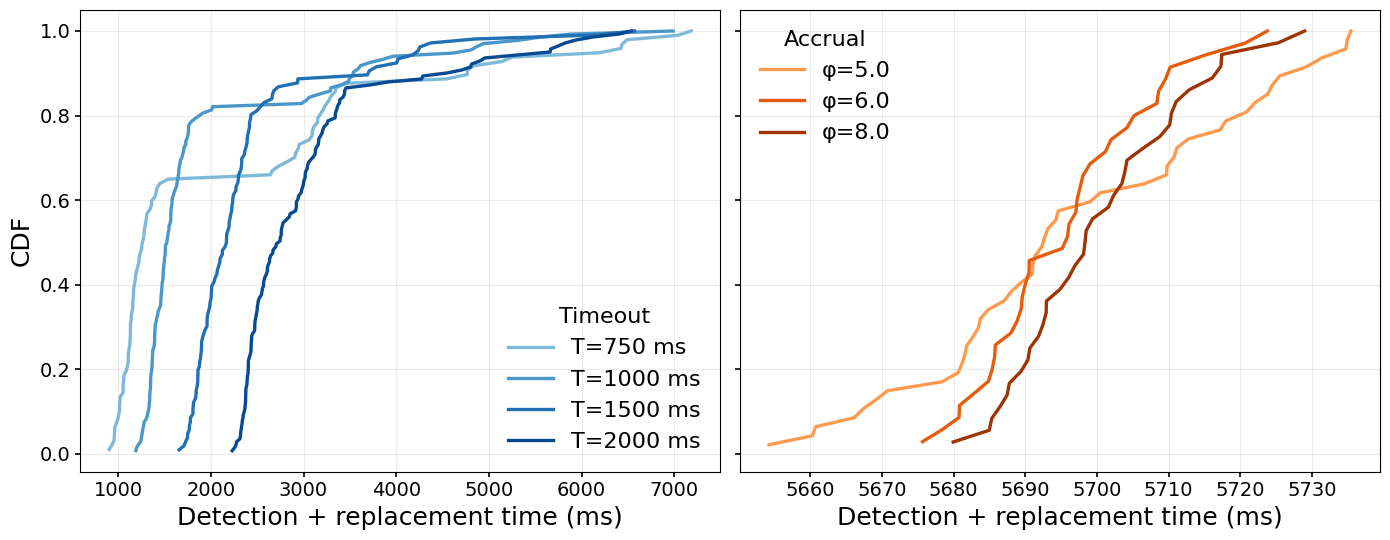

In [61]:
# ── CDF overlay: all schemes on one plot ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

cmap_t = plt.cm.Blues
cmap_a = plt.cm.Oranges

label_fs = 18
tick_fs = 14
legend_fs = 16
line_w = 2.4

for ax, params, name_fn, label_fn, cmap, legend_title in [
    (axes[0], TIMEOUT_PARAMS, timeout_name, lambda t, two_t: f"T={t} ms", cmap_t, "Timeout"),
    (axes[1], ACCRUAL_PARAMS, accrual_name, lambda phi: f"φ={phi}", cmap_a, "Accrual"),
]:
    valid = [(p, name_fn(*p) if isinstance(p, tuple) else name_fn(p)) for p in params]
    valid = [(p, n) for p, n in valid if not all_results.get(n, pd.DataFrame()).empty]
    colors = [cmap(0.45 + 0.45 * i / max(len(valid) - 1, 1)) for i in range(len(valid))]

    for (p, name), color in zip(valid, colors):
        ms = np.sort(all_results[name]["detection_ms"].values)
        cdf = np.arange(1, len(ms) + 1) / len(ms)
        lbl = label_fn(*p) if isinstance(p, tuple) else label_fn(p)
        ax.plot(ms, cdf, color=color, linewidth=line_w, label=lbl)

    ax.set_xlabel("Detection + replacement time (ms)", fontsize=label_fs)
    ax.grid(True, alpha=0.25, linewidth=0.8)
    ax.tick_params(axis="both", labelsize=tick_fs, width=1.2)
    ax.legend(title=legend_title, fontsize=legend_fs, title_fontsize=legend_fs, frameon=False)

axes[0].set_ylabel("CDF", fontsize=label_fs)

plt.tight_layout()
plt.show()


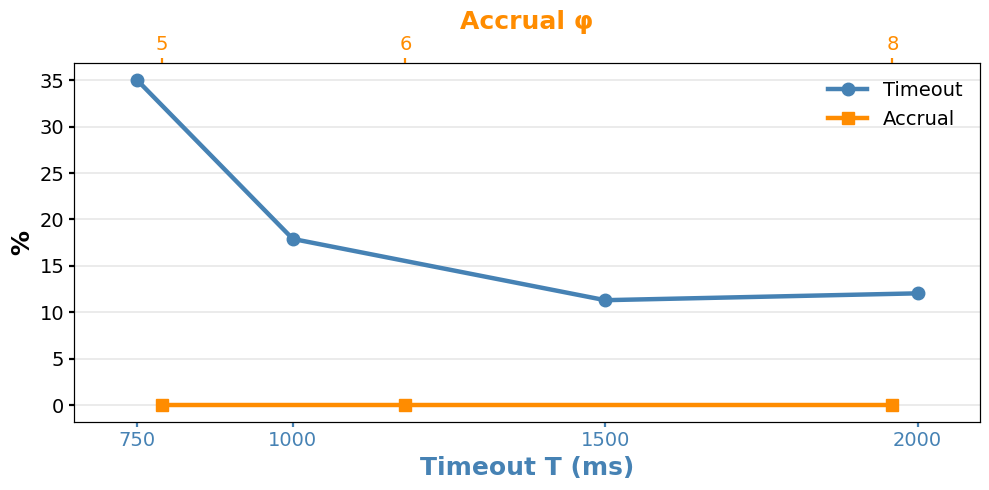

In [66]:
# ── Failed elections comparison (paper-style, single plot) ───────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax_top = ax.twiny()

handles = []

# Timeout (bottom x-axis)
if t_series:
    t_x = [x for x, _ in t_series]
    t_y = [s["pct_failed_elections"] for _, s in t_series]
    h1 = ax.plot(
        t_x, t_y,
        marker="o", markersize=9,
        linewidth=3.2, color="steelblue",
        label="Timeout"
    )[0]
    handles.append(h1)

    t_pad = (max(t_x) - min(t_x)) * 0.08 if len(t_x) > 1 else 1
    ax.set_xlim(min(t_x) - t_pad, max(t_x) + t_pad)
    ax.set_xticks(t_x)

# Accrual (top x-axis)
if a_series:
    a_x = [x for x, _ in a_series]
    a_y = [s["pct_failed_elections"] for _, s in a_series]
    h2 = ax_top.plot(
        a_x, a_y,
        marker="s", markersize=9,
        linewidth=3.2, color="darkorange",
        label="Accrual"
    )[0]
    handles.append(h2)

    a_pad = (max(a_x) - min(a_x)) * 0.12 if len(a_x) > 1 else 0.2
    ax_top.set_xlim(min(a_x) - a_pad, max(a_x) + a_pad)
    ax_top.set_xticks(a_x)

# Labels (no title)
label_fs = 18
tick_fs = 14
legend_fs = 14

ax.set_xlabel("Timeout T (ms)", fontsize=label_fs, fontweight="bold", color="steelblue")
ax_top.set_xlabel("Accrual φ", fontsize=label_fs, fontweight="bold", color="darkorange")
ax.set_ylabel("%", fontsize=label_fs, fontweight="bold")

ax.tick_params(axis="x", labelsize=tick_fs, colors="steelblue", width=1.6)
ax_top.tick_params(axis="x", labelsize=tick_fs, colors="darkorange", width=1.6)
ax.tick_params(axis="y", labelsize=tick_fs, width=1.6)

ax.grid(True, axis="y", alpha=0.3, linewidth=1.2)

if handles:
    ax.legend(handles=handles, loc="upper right", frameon=False, fontsize=legend_fs)

plt.tight_layout()
plt.show()


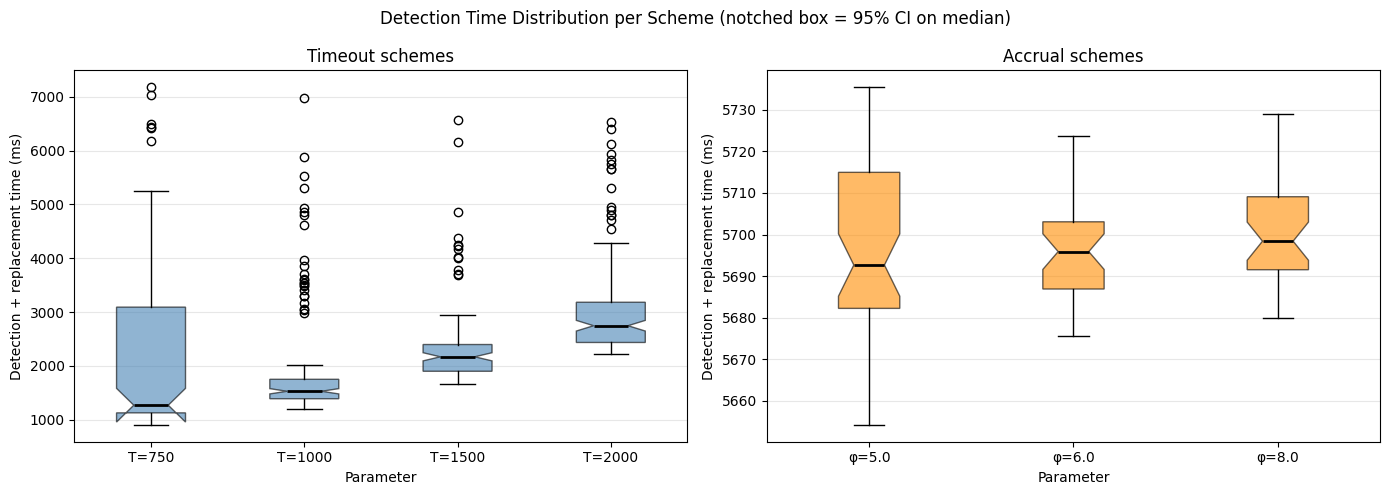

In [63]:
# ── Box plots: one box per scheme, side-by-side Timeout vs Accrual ───────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, params, name_fn, label_fn, color, scheme_label in [
    (axes[0], TIMEOUT_PARAMS, timeout_name, lambda t, two_t: f"T={t}",  "steelblue",  "Timeout"),
    (axes[1], ACCRUAL_PARAMS, accrual_name, lambda phi: f"φ={phi}",     "darkorange", "Accrual"),
]:
    groups  = []
    xlabels = []
    for p in params:
        name = name_fn(*p) if isinstance(p, tuple) else name_fn(p)
        df   = all_results.get(name, pd.DataFrame())
        if not df.empty:
            groups.append(df["detection_ms"].values)
            lbl = label_fn(*p) if isinstance(p, tuple) else label_fn(p)
            xlabels.append(lbl)

    if groups:
        bp = ax.boxplot(groups, patch_artist=True, notch=True,
                        medianprops=dict(color="black", linewidth=2))
        for patch in bp["boxes"]:
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        ax.set_xticks(range(1, len(xlabels) + 1))
        ax.set_xticklabels(xlabels)

    ax.set_xlabel("Parameter")
    ax.set_ylabel("Detection + replacement time (ms)")
    ax.set_title(f"{scheme_label} schemes")
    ax.grid(True, axis="y", alpha=0.3)

plt.suptitle("Detection Time Distribution per Scheme (notched box = 95% CI on median)")
plt.tight_layout()
plt.show()


## Summary table

In [64]:
rows = []
for (t, two_t) in TIMEOUT_PARAMS:
    name = timeout_name(t, two_t)
    s    = all_summaries.get(name)
    if s:
        rows.append({"scheme": "Timeout", "param": t, "name": name, **s})

for phi in ACCRUAL_PARAMS:
    name = accrual_name(phi)
    s    = all_summaries.get(name)
    if s:
        rows.append({"scheme": "Accrual", "param": phi, "name": name, **s})

summary_table = pd.DataFrame(rows).set_index(["scheme", "param"])
summary_table[["name", "n", "mean_ms", "ci95_ms", "median_ms",
               "p25_ms", "p75_ms", "p95_ms",
               "mean_failed_elections", "pct_failed_elections"]].round(1)


name    n  mean_ms  ci95_ms  median_ms  p25_ms  p75_ms  \
scheme  param                                                                   
Timeout 750.0    t_750_1500   97   2162.9    320.3     1268.9  1127.0  3092.4   
        1000.0  t_1000_2000  134   1962.1    185.7     1528.2  1389.4  1751.2   
        1500.0  t_1500_3000  106   2389.9    162.4     2169.1  1900.2  2397.3   
        2000.0  t_2000_4000  141   3050.9    156.3     2746.8  2435.2  3183.3   
Accrual 5.0           a_5_0   47   5697.2      6.3     5692.7  5682.3  5715.0   
        6.0           a_6_0   35   5695.8      3.9     5695.9  5686.9  5703.1   
        8.0           a_8_0   36   5700.4      3.9     5698.4  5691.5  5709.1   

                p95_ms  mean_failed_elections  pct_failed_elections  
scheme  param                                                        
Timeout 750.0   6235.1                    0.5                  35.1  
        1000.0  4679.7                    0.2                  17.9  
        1500.0  4219.6                    0.1                  11.3  
        2000.0  5660.7                    0.1                  12.1  
Accrual 5.0     5733.7                    0.0                   0.0  
        6.0     5716.7                    0.0                   0.0  
        8.0     5719.4                    0.0                   0.0